Markdown cell should be: GP_TensorFlow_CNN_Digits - Python - 2026-07-17 - DAMHAR2570

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the Digits dataset
digits = load_digits()
data = digits.data
target = digits.target

# Display dataset information
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(np.unique(target))}")
print(f"Classes: {np.unique(target)}")

### Step 1.2: Load the Dataset

Date: 2026-07-17

Student ID: DAMHAR2570

Data shape: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


### Step 1.3: Initial Exploration of the Dataset

Date: 2026-07-17

Student ID: DAMHAR2570

First few row of the data:
[[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
  15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
   0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
   0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]]


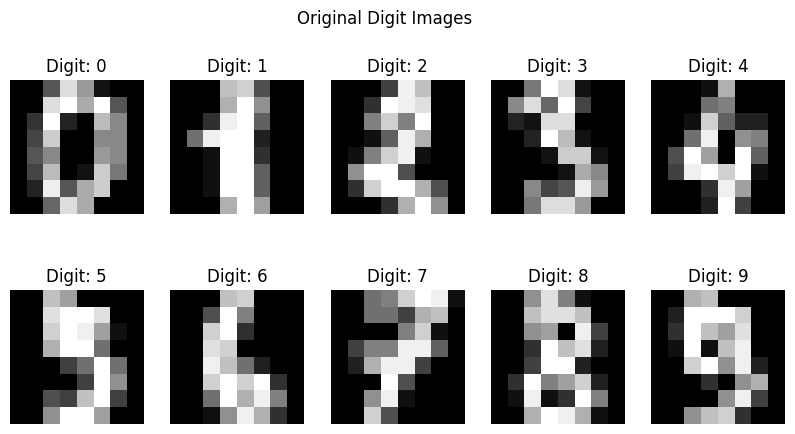

In [2]:
import matplotlib.pyplot as plt
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Display the first row of the data
print("First few row of the data:")
print(data[:1])

# Display original images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {target[i]}")
    ax.axis('off')
plt.suptitle('Original Digit Images')
plt.show()

### Step 1.4: Extracting Eigenvectors using PCA

Date: 2026-07-17

Student ID: DAMHAR2570

Explained Variance Ratio of PCA components:
[1.48905936e-01 1.36187712e-01 1.17945938e-01 8.40997942e-02
 5.78241466e-02 4.91691032e-02 4.31598701e-02 3.66137258e-02
 3.35324810e-02 3.07880621e-02 2.37234084e-02 2.27269657e-02
 1.82186331e-02 1.77385494e-02 1.46710109e-02 1.40971560e-02
 1.31858920e-02 1.24813782e-02 1.01771796e-02 9.05617439e-03
 8.89538461e-03 7.97123157e-03 7.67493255e-03 7.22903569e-03
 6.95888851e-03 5.96081458e-03 5.75614688e-03 5.15157582e-03
 4.89539777e-03 4.28887968e-03 3.73606048e-03 3.53274223e-03
 3.36683986e-03 3.28029851e-03 3.08320884e-03 2.93778629e-03
 2.56588609e-03 2.27742397e-03 2.22277922e-03 2.11430393e-03
 1.89909062e-03 1.58652907e-03 1.51159934e-03 1.40578764e-03
 1.16622290e-03 1.07492521e-03 9.64053065e-04 7.74630271e-04
 5.57211553e-04 4.04330693e-04 2.09916327e-04 8.24797098e-05
 5.25149980e-05 5.05243719e-05 3.29961363e-05 1.24365445e-05
 7.04827911e-06 3.01432139e-06 1.06230800e-06 5.50074587e-07
 3.42905702e-07 4.73963025e-19 0.00000000

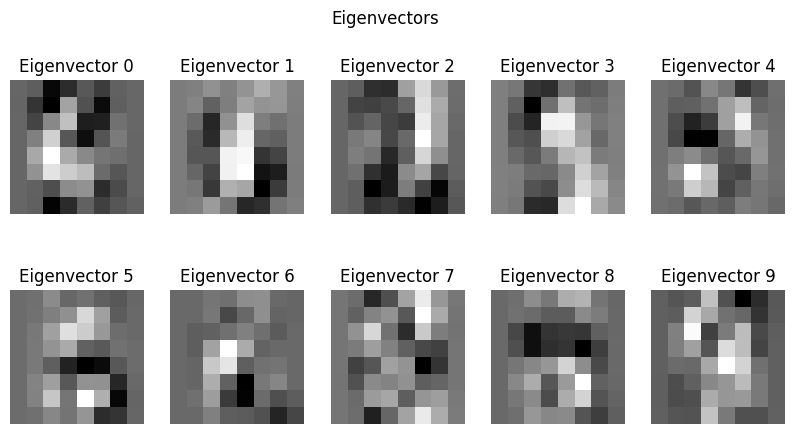

In [3]:
display(Markdown("### Step 1.4: Extracting Eigenvectors using PCA"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Initialize and fit PCA
pca = PCA(n_components=64)
data_pca = pca.fit_transform(data)

# Display the explained variance ratio
print("Explained Variance Ratio of PCA components:")
print(pca.explained_variance_ratio_)

# Display eigenvectors
fig, axes = plt.subplots(2, 5, figsize=(10, 5)) 
eigenvectors = pca.components_.reshape((64, 8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenvectors[i], cmap='gray')
    ax.set_title(f"Eigenvector {i}")
    ax.axis('off')
plt.suptitle('Eigenvectors')
plt.show()

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
display(Markdown("### Step 2.1: Prepare the Data for TensorFlow"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_pca, target, test_size=0.2, random_state=42)

# Reshape the data for CNN
X_train = X_train.reshape(-1, 8, 8, 1)
X_test = X_test.reshape(-1, 8, 8, 1)

# One-hot encode the target values
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Display the shape of the prepared data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

### Step 2.1: Prepare the Data for TensorFlow

Date: 2026-07-17

Student ID: DAMHAR2570

X_train shape: (1437, 8, 8, 1)
X_test shape: (360, 8, 8, 1)
y_train shape: (1437, 10)
y_test shape: (360, 10)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
display(Markdown("### Step 2.2: Building the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Initialize the model
model = Sequential()

# Add convolutional, pooling, and dense layers
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

### Step 2.2: Building the CNN Model

Date: 2026-07-17

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 6, 6, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,602 (150.79 KB)

 Trainable params: 38,602 (150.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
display(Markdown("### Step 2.3: Training the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Display the training history
print("Training history:")
print(history.history)

### Step 2.3: Training the CNN Model

Date: 2026-07-17

Student ID: DAMHAR2570

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2732 - loss: 2.1599 - val_accuracy: 0.7722 - val_loss: 0.9277
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8140 - loss: 0.7627 - val_accuracy: 0.8667 - val_loss: 0.4758
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9130 - loss: 0.3671 - val_accuracy: 0.8972 - val_loss: 0.3538
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9352 - loss: 0.2657 - val_accuracy: 0.9306 - val_loss: 0.2505
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9708 - loss: 0.1541 - val_accuracy: 0.9417 - val_loss: 0.2172
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9763 - loss: 0.1295 - val_accuracy: 0.9472 - val_loss: 0.1784
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9840 - loss: 0.0947 - val_accuracy: 0.9528 - val_loss: 0.1559
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9870 - loss: 0.0692 - val_accuracy: 0.9583 - val_loss

In [7]:
import keras_tuner as kt
display(Markdown("### Step 3.1: Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Define the hypermodel 
def build_model(hp): 
    model = Sequential()
    model.add(Conv2D(hp.Int('conv_units', min_value=32, max_value=128, step=32), kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize the tuner
tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=10, factor=3, directory='my_dir', project_name='hyperparam_tuning')

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal number of conv_units: {best_hps.get('conv_units')}")
print(f"Optimal number of dense_units: {best_hps.get('dense_units')}")

### Step 3.1: Hyperparameter Tuning

Date: 2026-07-17

Student ID: DAMHAR2570

Reloading Tuner from my_dir\hyperparam_tuning\tuner0.json
Optimal number of conv_units: 128
Optimal number of dense_units: 256


### Step 3.2: Evaluating the Model

Date: 2026-07-17

Student ID: DAMHAR2570

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9719 - loss: 0.1167 
Test accuracy: 0.9555555582046509
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


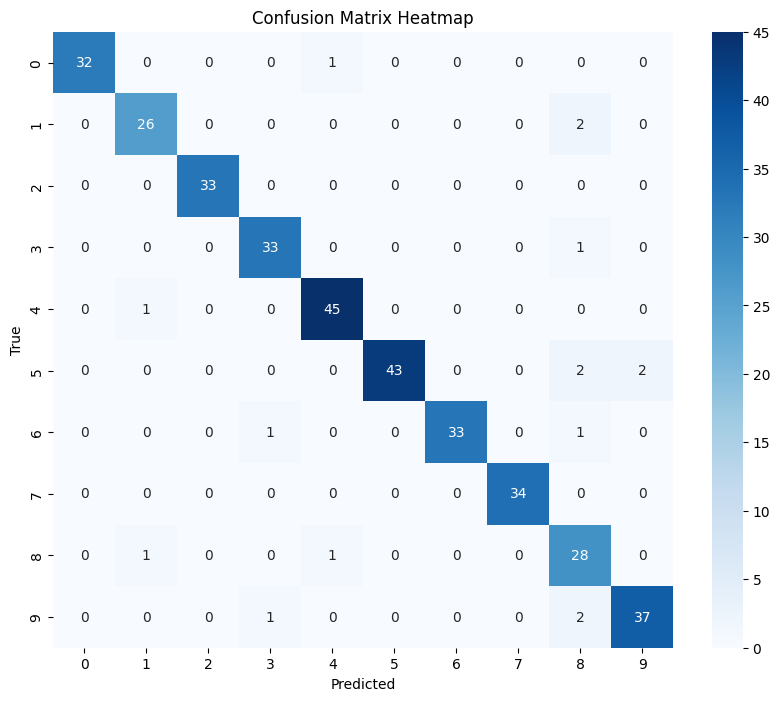

In [8]:
import seaborn as sns
display(Markdown("### Step 3.2: Evaluating the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Display the confusion matrix
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Step 3.3: Visualizing Training History

Date: 2026-07-17

Student ID: DAMHAR2570

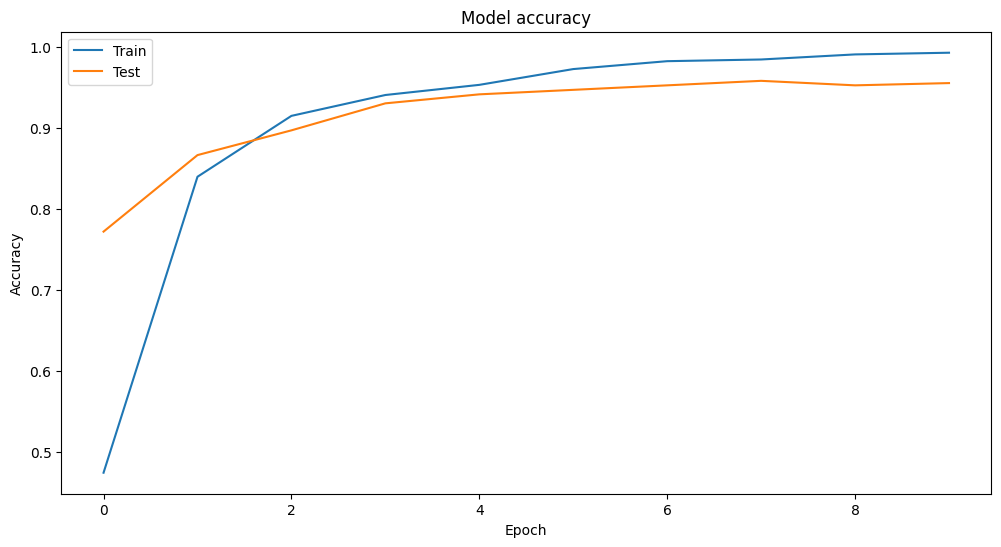

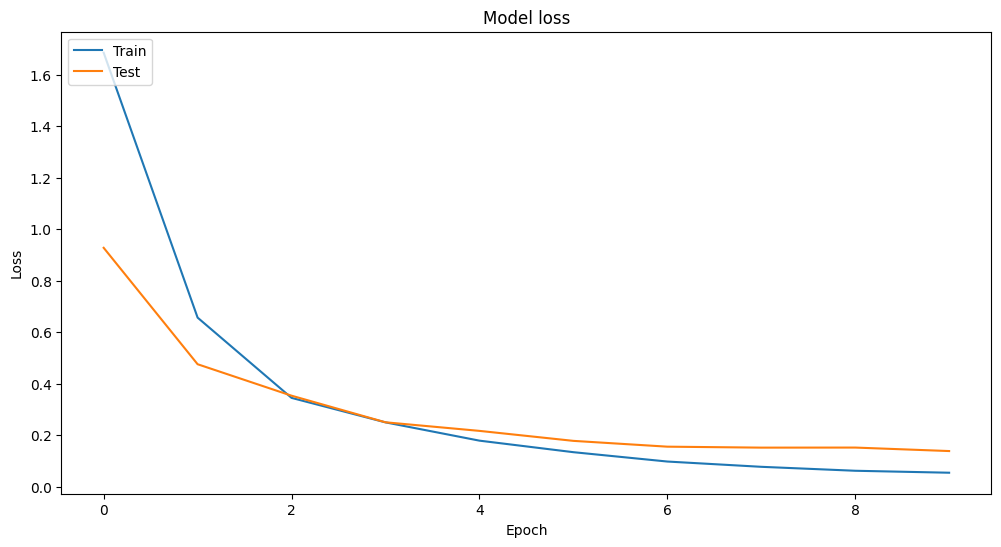

In [9]:
display(Markdown("### Step 3.3: Visualizing Training History"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Step 3.4: Applying the Best Hyperparameters and Visualizing the Results

Date: 2026-07-17

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5104 - loss: 1.5195 - val_accuracy: 0.9139 - val_loss: 0.3508
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9186 - loss: 0.3056 - val_accuracy: 0.9528 - val_loss: 0.1975
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9618 - loss: 0.1428 - val_accuracy: 0.9500 - val_loss: 0.1712
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9684 - loss: 0.1135 - val_accuracy: 0.9611 - val_loss: 0.1462
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9888 - loss: 0.0604 - val_accuracy: 0.9667 - val_loss: 0.1009
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9990 - loss: 0.0254 - val_accuracy: 0.9694 - val_loss: 0.1000
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.9639 - val_loss: 0.1062
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.9694 - va

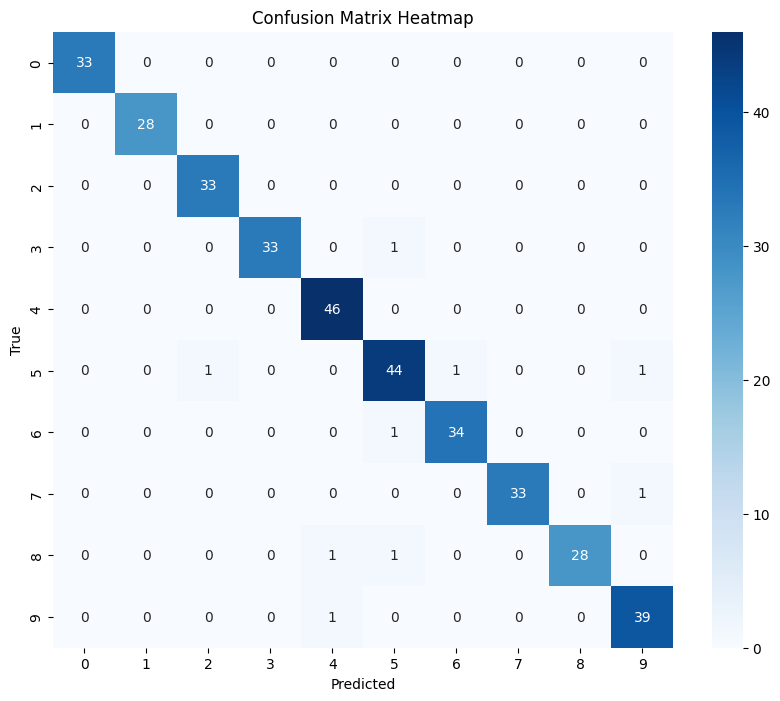

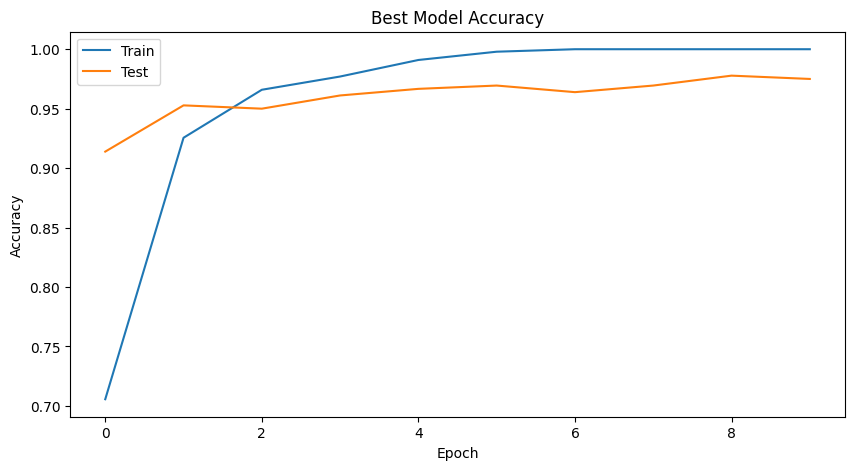

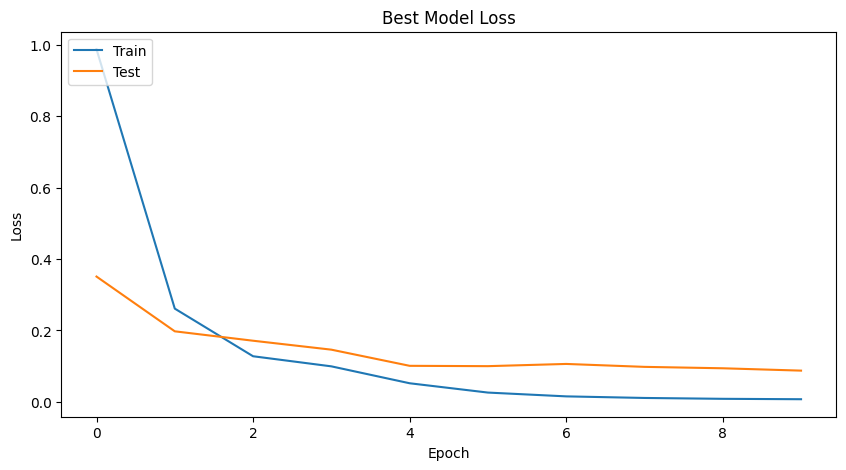

In [10]:
display(Markdown("### Step 3.4: Applying the Best Hyperparameters and Visualizing the Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Build the model with the best hyperparameters
best_model = Sequential()
best_model.add(Conv2D(best_hps.get('conv_units'), kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
best_model.add(MaxPooling2D(pool_size=(2, 2)))
best_model.add(Flatten())
best_model.add(Dense(best_hps.get('dense_units'), activation='relu'))
best_model.add(Dense(10, activation='softmax'))

# Compile the model
best_model.compile(optimizer='adam',
loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
best_history = best_model.fit(X_train, y_train, epochs=10,
validation_data=(X_test, y_test))

# Evaluate the model
best_test_loss, best_test_acc = best_model.evaluate(X_test, y_test)
print(f"Best Test accuracy: {best_test_acc}")

# Make predictions
best_y_pred = best_model.predict(X_test)
best_y_pred_classes = np.argmax(best_y_pred, axis=1)
best_y_true = np.argmax(y_test, axis=1)

# Display the confusion matrix
best_confusion_mtx = tf.math.confusion_matrix(best_y_true,
best_y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(best_confusion_mtx, annot=True, fmt='d', cmap='Blues',
xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Visualize training history
plt.figure(figsize=(10, 5))
plt.plot(best_history.history['accuracy'])
plt.plot(best_history.history['val_accuracy'])
plt.title('Best Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(best_history.history['loss'])
plt.plot(best_history.history['val_loss'])
plt.title('Best Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()